## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 06 · Calibrating the UBEM against DESNZ 2021 (Py-BOBYQA on the archetype tier)

Dogan et al. (2025) calibrate by minimising the error between simulated and billed energy with BOBYQA,
the parameters bounded by their archetype ranges (their eq. 10–11). EnerMap applies the same idea to the
ISO 52016 archetype tier, against the DESNZ sub-national gas and electricity statistics per LSOA — the
statistics every local authority has:

* **outer loop, Py-BOBYQA** on seven *physics* parameters that need a re-simulation of the
  representatives: wall / roof / window U scalers, infiltration scaler, internal-gains
  scaler, thermostat offset, and the background (setback) temperature outside the EFUS
  heating periods — CHAP delivers no heat there, so its level is left to the data;
* **nothing is fitted in post-processing**: the weather year, boiler efficiency, heat-pump seasonal
  performance and hot-water volumes are fixed from evidence (`parameters/demand_model/calibration.json`),
  so the electricity comparison is a prediction, not a fit;
* objective = meter-weighted squared relative error of the LSOA means, gas plus electricity, on the
  dwellings that existed in the benchmark year; households drawn with fixed seeds so the objective is
  deterministic; every evaluation is logged and the run resumes from its history.

Each outer evaluation simulates the representatives with three *stratified* household draws (a Latin hypercube
over the CHAP heating-regime shares and the thermostat distribution, so the mean is the archetype's expected
demand rather than the lottery of a few random households - the between-draw spread of a representative's
heat need is about ±50 %),
about 5 min on 32 cores; the budget of 36 evaluations takes about 3 h. Set `MAXFUN` higher for a tighter optimum.

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui
from ukubem.schedules import sample_household, dwelling_schedule
from ukubem.systems import delivered_energy, SYSTEM_DEFAULTS
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
from ukubem.calibrate import (ArchetypeCalibrator, PHYS_BOUNDS, POST_BOUNDS, POST_FIXED, make_representatives,
                              _stock_delivered, fit_post_params, objective_from_stock)
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
MAXFUN = 36
N_REAL = 3                       # stratified household draws per representative (Latin hypercube over regime and thermostat quantiles) = the archetype's expected intensity; about 6 min per evaluation on 32 cores
inputs0 = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
inputs, reps = make_representatives(inputs0)
inputs[["size_class"]].to_parquet(UBEM_OUT / "06_size_class.parquet"); reps.to_csv(UBEM_OUT / "06_representatives.csv", index=False)
history_path = UBEM_OUT / "06_calibration_history.csv"
cal = ArchetypeCalibrator(inputs=inputs, labels=labels, bench_lsoa=bench_lsoa, reps=reps, epw=str(EPW), pybui_src=str(PBE_SRC),
                          n_real=N_REAL, seed=SEED, n_jobs=N_JOBS, history_path=history_path)
print(f"{len(reps)} representatives; parameters: {list(PHYS_BOUNDS)} (outer) + {list(POST_BOUNDS)} (inner); fixed from evidence: {POST_FIXED}")

102 representatives; parameters: ['wall_u_scale', 'roof_u_scale', 'window_u_scale', 'infil_scale', 'gains_scale', 'setpoint_offset_c', 'setback_c'] (outer) + [] (inner); fixed from evidence: {'weather_scale': 1.0, 'boiler_eff': 0.82, 'hp_scop': 2.8, 'dhw_hp_scop': 2.0, 'dhw_scale': 1.0}


## 1 · Initial guess

In [3]:
# start from the exploratory single-draw fit of this tool (a transparent constant, not a file): BOBYQA spends
# 2n+1 evaluations on its first model whatever the start, a good start shortens the search after that
X0_WARM = {"wall_u_scale": 1.06, "roof_u_scale": 1.04, "window_u_scale": 1.20, "infil_scale": 1.03, "gains_scale": 0.92, "setpoint_offset_c": 0.7, "setback_c": 15.5}
x0 = {k: X0_WARM.get(k, v[2]) for k, v in PHYS_BOUNDS.items()}
MIN_EVALS_TO_REUSE = 12
REUSE = history_path.exists() and len(pd.read_csv(history_path)) >= MIN_EVALS_TO_REUSE
t0 = time.time()
if REUSE:      # never let the initial-guess evaluation overwrite a finished calibration history
    h0 = pd.read_csv(history_path); obj0 = float(h0["J"].iloc[0]); cal.post_last = dict(POST_FIXED)
    print(f"history with {len(h0)} evaluations found - initial guess read from it")
else:
    obj0 = cal.evaluate(np.array(list(x0.values())))
print(f"initial guess J {obj0:.4f} in {time.time()-t0:.0f} s; post-processing (all fixed from evidence): { {k: round(v, 3) for k, v in cal.post_last.items()} }")

eval   1  J 0.0279  gas WAPE 8.4% NMBE -6.9%  elec WAPE 10.8% NMBE +1.3%  phys wall_u=1.06 roof_u=1.04 window=1.20 infil_=1.03 gains_=0.92 setpoi=0.70 setbac=15.50  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [354 s]


initial guess J 0.0279 in 354 s; post-processing (all fixed from evidence): {'weather_scale': 1.0, 'boiler_eff': 0.82, 'hp_scop': 2.8, 'dhw_hp_scop': 2.0, 'dhw_scale': 1.0}


## 2 · Py-BOBYQA (resumable)

eval   2  J 0.0279  gas WAPE 8.4% NMBE -6.9%  elec WAPE 10.8% NMBE +1.3%  phys wall_u=1.06 roof_u=1.04 window=1.20 infil_=1.03 gains_=0.92 setpoi=0.70 setbac=15.50  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [346 s]


eval   3  J 0.0257  gas WAPE 7.0% NMBE -3.7%  elec WAPE 10.9% NMBE +1.6%  phys wall_u=1.15 roof_u=1.04 window=1.20 infil_=1.03 gains_=0.92 setpoi=0.70 setbac=15.50  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [335 s]


eval   4  J 0.0266  gas WAPE 7.7% NMBE -5.5%  elec WAPE 10.8% NMBE +1.4%  phys wall_u=1.06 roof_u=1.13 window=1.20 infil_=1.03 gains_=0.92 setpoi=0.70 setbac=15.50  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [341 s]


eval   5  J 0.0271  gas WAPE 8.0% NMBE -6.2%  elec WAPE 10.8% NMBE +1.3%  phys wall_u=1.06 roof_u=1.04 window=1.25 infil_=1.03 gains_=0.92 setpoi=0.70 setbac=15.50  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [333 s]


eval   6  J 0.0261  gas WAPE 7.3% NMBE -4.6%  elec WAPE 10.9% NMBE +1.6%  phys wall_u=1.06 roof_u=1.04 window=1.20 infil_=1.15 gains_=0.92 setpoi=0.70 setbac=15.50  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [339 s]


...

eval  34  J 0.0255  gas WAPE 7.1% NMBE -4.2%  elec WAPE 10.9% NMBE +1.6%  phys wall_u=1.06 roof_u=1.11 window=1.25 infil_=0.81 gains_=0.81 setpoi=0.91 setbac=15.61  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [285 s]


eval  35  J 0.0249  gas WAPE 6.5% NMBE -2.2%  elec WAPE 10.9% NMBE +1.9%  phys wall_u=1.04 roof_u=1.11 window=1.25 infil_=0.88 gains_=0.82 setpoi=1.00 setbac=15.63  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [283 s]


eval  36  J 0.0250  gas WAPE 6.6% NMBE -1.3%  elec WAPE 10.9% NMBE +1.9%  phys wall_u=1.06 roof_u=1.12 window=1.25 infil_=0.81 gains_=0.82 setpoi=0.97 setbac=15.96  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [286 s]


eval  37  J 0.0249  gas WAPE 6.6% NMBE -1.6%  elec WAPE 10.9% NMBE +1.9%  phys wall_u=1.07 roof_u=1.12 window=1.25 infil_=0.80 gains_=0.84 setpoi=1.00 setbac=15.86  post weathe=1.00 boiler=0.82 hp_sco=2.80 dhw_hp=2.00 dhw_sc=1.00  [286 s]



BOBYQA finished in 183.5 min: Warning (max evals): Objective has been called MAXFUN times


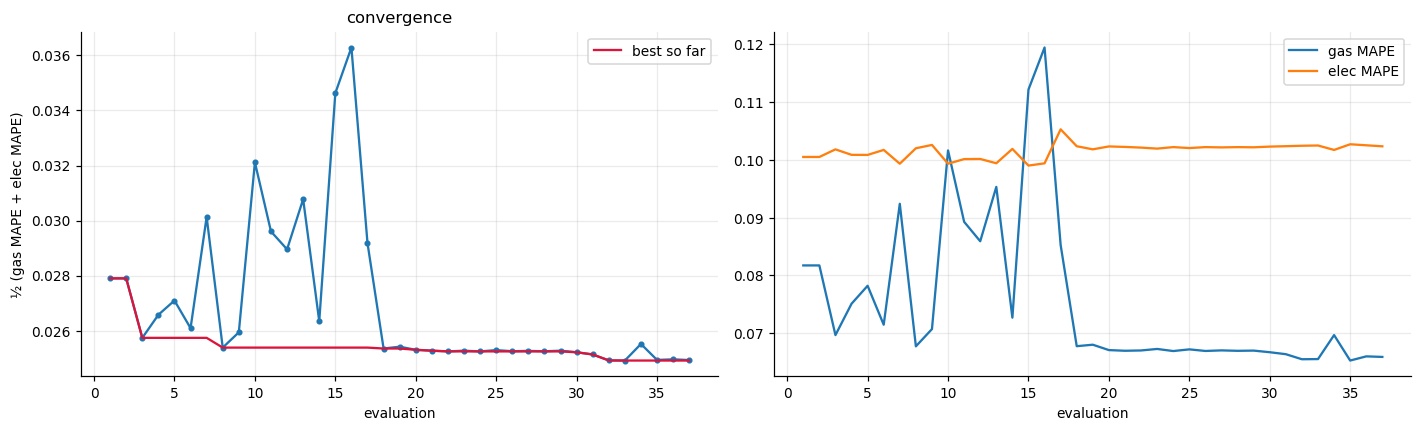

best evaluation: 33  objective 0.0249  gas 0.066  elec 0.103


wall_u_scale          1.065
roof_u_scale          1.125
window_u_scale        1.250
infil_scale           0.813
gains_scale           0.816
setpoint_offset_c     1.000
setback_c            15.691
weather_scale         1.000
boiler_eff            0.820
hp_scop               2.800
dhw_hp_scop           2.000
dhw_scale             1.000
dtype: float64

In [4]:
if REUSE:
    cal.history = pd.read_csv(history_path).to_dict("records")
    print(f"history with {len(cal.history)} evaluations found - not re-running (delete {history_path.name} to recalibrate)")
else:
    t0 = time.time()
    best_phys, sol = cal.run(maxfun=MAXFUN, rhobeg=0.15, x0=x0)
    print(f"\nBOBYQA finished in {(time.time()-t0)/60:.1f} min: {getattr(sol, 'msg', '')}")
hist = pd.DataFrame(cal.history)
best = hist.loc[hist["objective"].idxmin()]
theta_phys = {k: float(best[k]) for k in PHYS_BOUNDS}
theta_post = {k: float(best[k]) for k in [*POST_BOUNDS, *POST_FIXED]}
json.dump({"physics": theta_phys, "post": theta_post, "objective": float(best["objective"]),
           "gas_MAPE": float(best["gas_MAPE"]), "elec_MAPE": float(best["elec_MAPE"]), "n_evaluations": int(len(hist)),
           "bounds": {**PHYS_BOUNDS, **POST_BOUNDS}, "fixed": POST_FIXED}, open(UBEM_OUT / "06_calibrated_theta.json", "w"), indent=2)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist["eval"], hist["objective"], "o-", ms=3); axes[0].plot(hist["eval"], hist["objective"].cummin(), "-", color="crimson", label="best so far")
axes[0].set_xlabel("evaluation"); axes[0].set_ylabel("½ (gas MAPE + elec MAPE)"); axes[0].legend(); axes[0].set_title("convergence")
axes[1].plot(hist["eval"], hist["gas_MAPE"], label="gas MAPE"); axes[1].plot(hist["eval"], hist["elec_MAPE"], label="elec MAPE"); axes[1].legend(); axes[1].set_xlabel("evaluation")
plt.tight_layout(); fig.savefig(FIG_UBEM / "06_convergence.png", bbox_inches="tight"); plt.show()
print("best evaluation:", int(best["eval"]), " objective %.4f  gas %.3f  elec %.3f" % (best["objective"], best["gas_MAPE"], best["elec_MAPE"]))
pd.Series({**theta_phys, **theta_post}).round(3)

## 3 · Calibrated parameters and the bounds

In [5]:
rows = []
for k, (lo, hi, x0_) in {**PHYS_BOUNDS, **POST_BOUNDS}.items():
    rows.append({"parameter": k, "lower": lo, "upper": hi, "initial": x0_, "ISO52016 archetype tier": {**theta_phys, **theta_post}[k]})
for k, v in POST_FIXED.items():
    rows.append({"parameter": k, "lower": v, "upper": v, "initial": v, "ISO52016 archetype tier": v})
comp = pd.DataFrame(rows).set_index("parameter")
comp["status"] = ["fixed (evidence)" if k in POST_FIXED else "fitted" for k in comp.index]
comp["at_bound"] = (comp["status"].eq("fitted")) & (((comp["ISO52016 archetype tier"] - comp["lower"]).abs() < 1e-3) | ((comp["upper"] - comp["ISO52016 archetype tier"]).abs() < 1e-3))
comp.to_csv(UBEM_OUT / "06_theta_comparison.csv")
comp.round(3)

,lower,upper,initial,ISO52016 archetype tier,status,at_bound
parameter,,,,,,
wall_u_scale,0.70,1.30,1.00,1.065,fitted,False
roof_u_scale,0.70,1.30,1.00,1.125,fitted,False
window_u_scale,0.85,1.25,1.00,1.250,fitted,True
infil_scale,0.70,1.50,1.00,0.813,fitted,False
gains_scale,0.70,1.30,1.00,0.816,fitted,False
setpoint_offset_c,-1.50,1.00,0.00,1.000,fitted,True
setback_c,10.00,18.00,12.00,15.691,fitted,False
weather_scale,1.00,1.00,1.00,1.000,fixed (evidence),False
boiler_eff,0.82,0.82,0.82,0.820,fixed (evidence),False


## 4 · Calibrated baseline: the LSOA fit

calibrated LSOA: {'gas_MAPE': 0.066, 'elec_MAPE': 0.103, 'gas_bias': -0.017, 'elec_bias': 0.034, 'gas_WAPE_pct': 6.54, 'elec_WAPE_pct': 10.922, 'gas_NMBE_pct': -2.059, 'elec_NMBE_pct': 1.849, 'gas_R2_predictive': 0.915, 'elec_R2_predictive': 0.717, 'J_gas': 0.008, 'J_elec': 0.017}


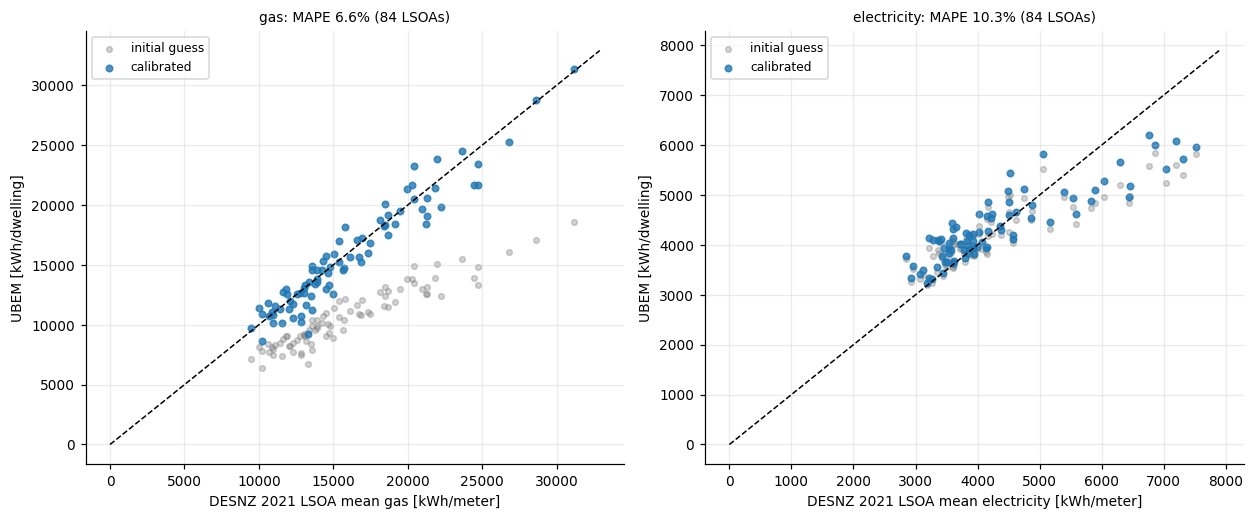

In [6]:
inten_cal = cal.simulate(theta_phys)
inten_cal.to_csv(UBEM_OUT / "06_archetype_intensities_calibrated.csv")
stock_cal = _stock_delivered(inputs, inten_cal, theta_post)
stock_cal.to_parquet(UBEM_OUT / "06_stock_calibrated.parquet")
t_cal = aggregate_lsoa(stock_cal, labels, bench_lsoa); m_cal = mape(t_cal); t_cal.to_csv(UBEM_OUT / "06_lsoa_calibrated.csv")
t0_ = pd.read_csv(UBEM_OUT / "05_lsoa_initial_guess.csv", index_col=0) if (UBEM_OUT / "05_lsoa_initial_guess.csv").exists() else None
print("calibrated LSOA:", {k: round(v, 3) for k, v in m_cal.items()})
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, (sim, obs, ttl, key) in zip(axes, [("sim_gas_mean_kWh", "gas_mean_kWh", "gas", "gas"), ("sim_elec_mean_kWh", "elec_mean_kWh", "electricity", "elec")]):
    tt = t_cal.dropna(subset=[obs, sim]); lim = [0, max(tt[obs].max(), tt[sim].max()) * 1.05]
    if t0_ is not None:
        ax.scatter(t0_[obs], t0_[sim], s=14, alpha=0.35, color="grey", label="initial guess")
    ax.scatter(tt[obs], tt[sim], s=18, alpha=0.8, label="calibrated"); ax.plot(lim, lim, "k--", lw=1); ax.legend(fontsize=8)
    ax.set_xlabel(f"DESNZ 2021 LSOA mean {ttl} [kWh/meter]"); ax.set_ylabel("UBEM [kWh/dwelling]"); ax.set_title(f"{ttl}: MAPE {m_cal[key + '_MAPE']:.1%} (84 LSOAs)", fontsize=9)
plt.tight_layout(); fig.savefig(FIG_UBEM / "06_calibrated_fit.png", bbox_inches="tight"); plt.show()

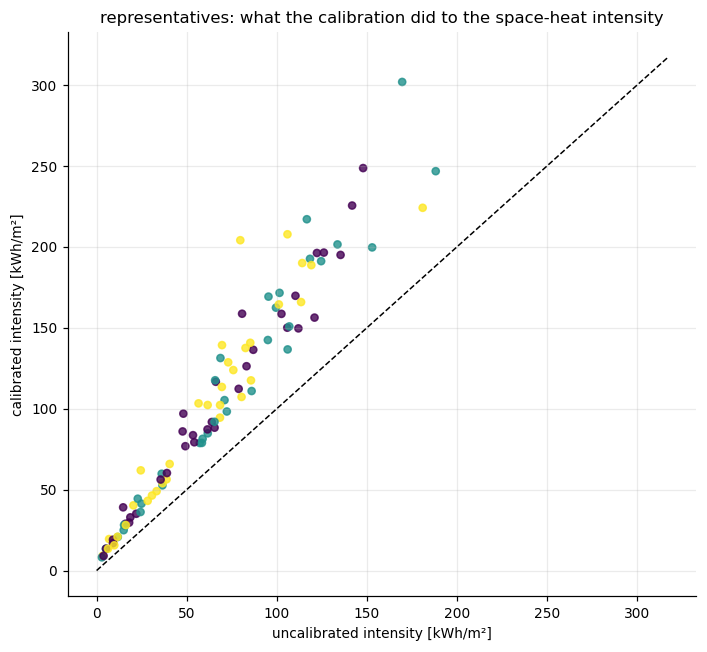

mean winter operative temperature of the representatives: 19.3 °C (EFUS/CHAP mean ≈ 18-19 °C)


In [7]:
# what the calibration did to the archetype intensities
inten0 = pd.read_csv(UBEM_OUT / "05_archetype_intensities.csv", index_col=0) if (UBEM_OUT / "05_archetype_intensities.csv").exists() else None
if inten0 is not None:
    j = inten_cal.join(inten0[["Q_H_kWh_m2"]].rename(columns={"Q_H_kWh_m2": "initial"}), how="inner")
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.scatter(j["initial"], j["Q_H_kWh_m2"] * theta_post["weather_scale"], s=22, alpha=0.8, c=j["size_class"].map({"S": 0, "M": 1, "L": 2}), cmap="viridis")
    lim = [0, j[["initial", "Q_H_kWh_m2"]].max().max() * 1.05]; ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("uncalibrated intensity [kWh/m²]"); ax.set_ylabel("calibrated intensity [kWh/m²]"); ax.set_title("representatives: what the calibration did to the space-heat intensity")
    plt.tight_layout(); fig.savefig(FIG_UBEM / "06_intensities_before_after.png", bbox_inches="tight"); plt.show()
print(f"mean winter operative temperature of the representatives: {inten_cal['T_op_winter'].mean():.1f} °C (EFUS/CHAP mean ≈ 18-19 °C)")

**Next:** `07_spatial_cv.ipynb` — the transfer test of the calibration; `08_dwelling_tier_check.ipynb` — the calibrated model on individual dwellings.